# IdiomX: English–Arabic Idiom Understanding

This notebook explores the official IdiomX dataset before task-specific splitting and model training.

## Goals
- Load the official dataset
- Inspect structure and columns
- Perform exploratory data analysis (EDA)
- Visualize distributions
- Understand data quality and completeness
- Identify useful fields for downstream tasks
- Document key findings for research use

In [1]:
# {Setup}
# =========================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

SEED = 42
np.random.seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Download or Load Official Dataset

This section downloads the official IdiomX dataset locally if it does not already exist.
The default source is Hugging Face, with the dataset stored under `data/raw/`.

In [2]:
# Paths
# =========================================

from pathlib import Path
import pandas as pd

BASE_DIR = Path("..").resolve()
DATA_RAW_DIR = BASE_DIR / "data" / "raw"
DATA_RAW_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_DATA_PATH = DATA_RAW_DIR / "idiomx_official.csv"

print("BASE_DIR       :", BASE_DIR)
print("DATA_RAW_DIR   :", DATA_RAW_DIR)
print("LOCAL_DATA_PATH:", LOCAL_DATA_PATH)

BASE_DIR       : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX
DATA_RAW_DIR   : C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\data\raw
LOCAL_DATA_PATH: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\data\raw\idiomx_official.csv


## 1. Download IdiomX Dataset 

In [3]:
# Download from Hugging Face if file does not exist
# =========================================

if not LOCAL_DATA_PATH.exists():
    print("Local dataset not found. Downloading from Hugging Face...")

    try:
        from datasets import load_dataset

        ds = load_dataset("aymansharara/IdiomX")
        
        # Try common split names
        if "train" in ds:
            df = ds["train"].to_pandas()
        else:
            # fallback: merge all available splits if needed
            parts = []
            for split_name in ds.keys():
                parts.append(ds[split_name].to_pandas())
            df = pd.concat(parts, ignore_index=True)

        df.to_csv(LOCAL_DATA_PATH, index=False, encoding="utf-8-sig")
        print("Dataset downloaded and saved locally.")
        print("Shape:", df.shape)

    except Exception as e:
        print("Hugging Face download failed.")
        print("Error:", e)
else:
    print("Local dataset already exists. Skipping download.")

Local dataset not found. Downloading from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


idiomx.parquet:   0%|          | 0.00/31.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/123336 [00:00<?, ? examples/s]

Dataset downloaded and saved locally.
Shape: (123336, 34)


In [4]:
# Optional fallback — Download from Kaggle
# =========================================

if not LOCAL_DATA_PATH.exists():
    print("Trying Kaggle fallback...")

    try:
        import kagglehub
        import shutil

        kaggle_path = kagglehub.dataset_download("aymansharara/idiomx")
        kaggle_path = Path(kaggle_path)

        print("Kaggle dataset downloaded to:", kaggle_path)

        # Try to find a CSV file inside the downloaded folder
        csv_files = list(kaggle_path.rglob("*.csv"))
        if not csv_files:
            raise FileNotFoundError("No CSV file found inside Kaggle dataset download.")

        source_csv = csv_files[0]
        shutil.copy(source_csv, LOCAL_DATA_PATH)

        print("Copied dataset to:", LOCAL_DATA_PATH)

    except Exception as e:
        print("Kaggle download failed.")
        print("Error:", e)

## 2. Load local dataset

In [5]:
# Load local dataset
# =========================================

df = pd.read_csv(LOCAL_DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (123336, 34)


## 3. Dataset Structure

In this section, we inspect:
- column names
- data types
- a few sample rows

This helps us understand the dataset schema before deeper analysis.

In [7]:
# 3.1 Basic structure
# =========================================

print("Number of rows   :", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:02d}. {col}")

Number of rows   : 123336
Number of columns: 34

Columns:
01. idiom
02. meaning_en
03. example
04. source
05. source_type
06. pos
07. tags
08. idiom_confidence
09. source_url
10. idiom_canonical
11. idiom_canonical_meaning
12. idiom_canonical_meaning_arabic
13. is_idiom
14. ambiguity_flag
15. idiom_compositionality_level
16. idiom_register
17. idiom_domain
18. learner_difficulty
19. idiom_surface
20. idiom_in_example
21. idiom_in_example_arabic
22. idiom_in_example_meaning_en
23. idiom_in_example_meaning_arabic
24. is_example_idiom
25. example_usage_label
26. is_generated_example
27. enrichment_model
28. enrichment_version
29. validation_status
30. example_length
31. idiom_present
32. contains_profanity
33. semantic_consistency
34. canonical_semantic_score


In [8]:
# 3.2 — Data types
# =========================================

dtype_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notnull().sum().values,
    "null_count": df.isnull().sum().values
})

display(dtype_df)

,column,dtype,non_null_count,null_count
0,idiom,object,123336,0
1,meaning_en,object,123336,0
2,example,object,78032,45304
3,source,object,123336,0
4,source_type,object,123336,0
5,pos,object,123336,0
6,tags,object,96360,26976
7,idiom_confidence,object,123336,0
8,source_url,float64,0,123336
9,idiom_canonical,object,123152,184


In [10]:

# 3.3 — Sample rows
# =========================================

display(df.head(1))

,idiom,meaning_en,example,source,source_type,pos,tags,idiom_confidence,source_url,idiom_canonical,idiom_canonical_meaning,idiom_canonical_meaning_arabic,is_idiom,ambiguity_flag,idiom_compositionality_level,idiom_register,idiom_domain,learner_difficulty,idiom_surface,idiom_in_example,idiom_in_example_arabic,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,is_example_idiom,example_usage_label,is_generated_example,enrichment_model,enrichment_version,validation_status,example_length,idiom_present,contains_profanity,semantic_consistency,canonical_semantic_score
0,$100 hamburger,Used other than figuratively or idiomatically: see hamburger.,Daniel Boulud has a restaurant that serves a truffle and Kobe steak hamburger for $100 […] It's to make everything e...,kaikki_wiktionary,dictionary,noun,NaN,high,NaN,$100 hamburger,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ...",True,ambiguous,semi_opaque,neutral,regional,medium,$100 hamburger,"Last weekend, Mark took a $100 hamburger trip just to enjoy flying and have lunch at a local diner.","في نهاية الأسبوع الماضي، قام مارك برحلة ""همبرغر بمئة دولار"" فقط للاستمتاع بالطيران وتناول الغداء في مطعم محلي.",The expression figuratively means that Mark flew purely for pleasure and to justify flying expense by having a simpl...,يعني التعبير مجازياً أن مارك طار فقط للمتعة ولتبرير تكلفة الطيران بتناول وجبة بسيطة في مطار آخر.,True,idiomatic,1,gpt-4.1-mini-2025-04-14,v2_4idiomatic_4literal,valid,19.0,True,False,0.593185,0.762083


In [11]:
# 4. Group columns by purpose
# =========================================

core_columns = [
    "idiom",
    "idiom_canonical",
    "idiom_surface",
    "meaning_en",
    "idiom_canonical_meaning",
    "idiom_canonical_meaning_arabic"
]

example_columns = [
    "example",
    "idiom_in_example",
    "idiom_in_example_arabic",
    "idiom_in_example_meaning_en",
    "idiom_in_example_meaning_arabic",
    "is_example_idiom",
    "example_usage_label",
    "is_generated_example",
    "example_length",
    "idiom_present"
]

label_columns = [
    "is_idiom",
    "ambiguity_flag",
    "idiom_compositionality_level",
    "idiom_register",
    "idiom_domain",
    "learner_difficulty"
]

quality_columns = [
    "semantic_consistency",
    "canonical_semantic_score",
    "validation_status",
    "contains_profanity"
]

metadata_columns = [
    "source",
    "source_type",
    "pos",
    "tags",
    "idiom_confidence",
    "source_url",
    "enrichment_model",
    "enrichment_version"
]

print("Core columns:", len(core_columns))
print("Example columns:", len(example_columns))
print("Label columns:", len(label_columns))
print("Quality columns:", len(quality_columns))
print("Metadata columns:", len(metadata_columns))

Core columns: 6
Example columns: 10
Label columns: 6
Quality columns: 4
Metadata columns: 8


In [12]:
# Verify all columns are covered

all_grouped = set(
    core_columns +
    example_columns +
    label_columns +
    quality_columns +
    metadata_columns
)

missing = set(df.columns) - all_grouped

print("Columns NOT grouped:", missing)

Columns NOT grouped: set()


In [13]:
# Quick view of core columns only (important for modeling)

display(df[core_columns].head(5))

,idiom,idiom_canonical,idiom_surface,meaning_en,idiom_canonical_meaning,idiom_canonical_meaning_arabic
0,$100 hamburger,$100 hamburger,$100 hamburger,Used other than figuratively or idiomatically: see hamburger.,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ..."
1,$100 hamburger,$100 hamburger,$100 hamburger,Used other than figuratively or idiomatically: see hamburger.,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ..."
2,$100 hamburger,$100 hamburger,$100 hamburger,Used other than figuratively or idiomatically: see hamburger.,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ..."
3,$100 hamburger,$100 hamburger,$100 hamburger,Used other than figuratively or idiomatically: see hamburger.,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ..."
4,$100 hamburger,$100 hamburger,$100 hamburger,Used other than figuratively or idiomatically: see hamburger.,"In aviation and pilot culture, a ""$100 hamburger"" refers to a flight solely undertaken to justify the expense of fly...","في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول ..."


In [38]:
# random sample
sample_random = df.sample(5, random_state=42)[[
    "idiom_canonical",
    "idiom_in_example",
    "idiom_in_example_meaning_en",
    "example_usage_label"
]]

sample_random

,idiom_canonical,idiom_in_example,idiom_in_example_meaning_en,example_usage_label
109809,tick over,The old machinery can only tick over at half speed until repairs are done.,"The machinery operates at a slow but continuous pace, not its full capacity, until fixed.",idiomatic
6351,all in a day's work,"The farmer repaired fences, fed animals, and harvested crops—all in a day's work.",A literal description of multiple farm tasks completed in one workday.,literal
13145,bet the ranch,The startup decided to bet the ranch by investing all its capital into a single product launch.,The startup risked all its capital on one product launch.,idiomatic
64794,loosen the purse strings,"If we want to improve the education system, we need to loosen the purse strings and invest more money.",More financial resources must be allocated by relaxing spending limits.,idiomatic
84136,pull strings,We know who pulls the strings around here.,Someone controls or influences the situation behind the scenes.,idiomatic


In [41]:
# Random sample per label (literal vs idiomatic)
sample_per_label = (
    df.groupby("example_usage_label")
      .sample(5, random_state=42)
      [[
          "idiom_canonical",
          "idiom_in_example",
          "idiom_in_example_meaning_en",
          "example_usage_label"
      ]]
)

sample_per_label

,idiom_canonical,idiom_in_example,idiom_in_example_meaning_en,example_usage_label
25427,count noses,"When organizing the conference, the coordinator needed to count noses to arrange sufficient seating.",To determine the exact number of attendees to prepare adequate seating.,idiomatic
121793,"write once, read many","The new regulation is a write once, read many policy to prevent unauthorized edits.",Refers figuratively to a policy that is fixed once created and accessed many times without modification.,idiomatic
89737,run adrift,run adrift,The project seemed to run adrift after key members left the company.,idiomatic
59368,kick up a stew,kick up a stew,"To create a noisy commotion or disturbance, often as a protest or reaction to something unpleasant.",idiomatic
30011,"dogs have masters, cats have staff",Yes,"My grandfather used to say 'dogs have masters, cats have staff' to describe the distinct temperaments of pets and pe...",idiomatic
1077,German virgin,German virgin,"The novel featured a character described as a German virgin, emphasizing her culture and innocence.",literal
106317,the best defense is a good offense,"The castle was built with strong walls, but the soldiers knew the best defense is a good offense and often launched ...",Literally describing a military tactic where offensive actions are used to defend a stronghold.,literal
56841,is anyone sitting here,"In the crowded café, she politely asked, 'Is anyone sitting here?' before taking the empty chair.","Someone asking if the seat near another person is occupied, to know if they can sit down.",literal
89509,rubber chicken,She bought a rubber chicken to use as a prop for her comedy show.,She purchased a rubber toy chicken to use as a comedic prop.,literal
50169,high quality rip,high quality rip,The act of producing a very good digital copy from an original source.,literal


    Examples labeled idiomatic correctly represent figurative usage. 
    Literal labels are also mostly correct.
This indicates the dataset correctly differentiates figurative vs literal usage

In [43]:
#Random sample per compositionality level
sample_compositionality = (
    df.groupby("idiom_compositionality_level")
      .sample(3, random_state=42)
      [[
          "idiom_canonical",
          "idiom_in_example",
          "idiom_in_example_meaning_en",
          "example_usage_label",
          "idiom_compositionality_level"
      ]]
)

sample_compositionality

,idiom_canonical,idiom_in_example,idiom_in_example_meaning_en,example_usage_label,idiom_compositionality_level
60414,lap of luxury,"The baby rested peacefully in the lap of luxury, lying on his mother’s soft hands.","The baby literally lay in someone's lap, feeling physical comfort and safety.",literal,opaque
98017,"sow the wind, reap the whirlwind","The company’s reckless policies sowed the wind, and soon they were forced to face the whirlwind of public backlash a...",The company’s careless actions led to major negative consequences.,idiomatic,opaque
49840,"here's a quarter, call someone who cares","here's a quarter, call someone who cares","an expression used to abruptly dismiss someone’s complaint or concern, showing that the speaker does not care",idiomatic,opaque
68269,mince words,mince words,They learnt how to mince words of herbs and spices during the cooking class today.,literal,semi_opaque
102785,take a bite,She decided to take a bite at learning the new language despite the difficulty.,"To try or attempt to do something challenging, here learning a language.",idiomatic,semi_opaque
14147,bite to eat,She stopped by the deli for a bite to eat during her lunch break.,A quick meal or snack during a break.,idiomatic,semi_opaque
121540,worth every penny,That old vase is worth every penny inscribed on it because the number marks its authenticity.,The vase literally has pennies marked on it that give it value.,literal,transparent
83593,professional student,professional student,Describes a person who seems to treat studying as a lifelong occupation and avoids entering the job market.,idiomatic,transparent
103,51 percent,51 percent battery,My phone’s battery is currently at 51 percent charge.,literal,transparent


In [46]:
# Random sample of difficult idioms
sample_hard = df[df["learner_difficulty"] == "hard"].sample(5)[[
    "idiom_canonical",
    "idiom_in_example",
    "idiom_in_example_meaning_en",
    "example_usage_label"
]]

sample_hard

,idiom_canonical,idiom_in_example,idiom_in_example_meaning_en,example_usage_label
104501,take up the cudgels,The child was taught to take up the cudgels only when necessary to protect himself in the forest.,The child was taught to pick up a stick as a physical weapon for protection.,literal
51823,horizontal jogging,"During the team training, players practiced horizontal jogging drills to improve lateral speed and agility.",Literal sports training focused on sideways jogging exercises.,literal
14958,bloom is off the rose,bloom is off the peach,There are no longer any flowers blooming on the peach tree.,literal
107781,the world is too much with someone,the world was too much with the ship,The external conditions on the ship (like wind or waves) were overwhelming or difficult to handle.,literal
113306,turn with every wind,"In the debate, he turned with every wind, never committing to a clear stance.","He changed his opinions repeatedly depending on how the situation evolved, showing inconsistency.",idiomatic


In [47]:
# Edge cases (very short / very long examples)
df["example_length"] = df["idiom_in_example"].str.split().str.len()

short_examples = df.nsmallest(10, "example_length")[[
    "idiom_canonical",
    "idiom_in_example",
    "idiom_in_example_meaning_en"
]]

long_examples = df.nlargest(10, "example_length")[[
    "idiom_canonical",
    "idiom_in_example",
    "idiom_in_example_meaning_en"
]]


In [50]:
short_examples.head(3)

,idiom_canonical,idiom_in_example,idiom_in_example_meaning_en
508,Chinese cherry,cherry,"She described the success of the project as the cherry on top of their efforts, symbolizing the best part."
509,Chinese cherry,cherry,"His explanation was the cherry that completed the whole story perfectly, adding the crucial detail."
510,Chinese cherry,cherry,Winning the championship was the cherry that crowned their hard work throughout the season.


In [51]:
long_examples.head(3)

,idiom_canonical,idiom_in_example,idiom_in_example_meaning_en
81864,pleased with oneself,Nixon confirmed that the Chinese Communists at first demanded that throughout the communique Taiwan be referred to a...,He felt self-satisfied and proud about his handling of the diplomatic phrasing issue.
67344,marsh light,"Thus, even thus, have I lived for full two thousand years - for some six and sixty generations, as ye reckon time - ...","Figurative use describing hope as deceptive, like flickering lights in marshes that appear guiding but are false."
17904,buckle to,"Then the sergeant let us out, and introducing us to a pile of wood and saws and axes, informed us that when this had...",The phrase means that we started working hard and seriously on the task at hand (cutting firewood).


In [52]:
bad_words = ["fuck", "shit", "ass", "damn"]

df["contains_profanity"] = (
    df["idiom_canonical"]
    .fillna("")                # handle NaN
    .astype(str)
    .str.lower()
    .apply(lambda x: any(word in x for word in bad_words))
)

In [14]:
# 5. Null analysis (top important columns)
# =========================================

important_cols = [
    "idiom",
    "idiom_canonical",
    "idiom_surface",
    "example",
    "idiom_in_example",
    "idiom_in_example_meaning_en",
    "idiom_in_example_meaning_arabic",
    "meaning_en",
    "idiom_canonical_meaning",
    "idiom_canonical_meaning_arabic"
]

null_stats = pd.DataFrame({
    "column": important_cols,
    "null_count": [df[c].isnull().sum() for c in important_cols],
    "null_%": [round(df[c].isnull().mean() * 100, 2) for c in important_cols]
})

display(null_stats.sort_values("null_%", ascending=False))

,column,null_count,null_%
3,example,45304,36.73
8,idiom_canonical_meaning,1056,0.86
9,idiom_canonical_meaning_arabic,1032,0.84
1,idiom_canonical,184,0.15
5,idiom_in_example_meaning_en,10,0.01
0,idiom,0,0.00
2,idiom_surface,1,0.00
4,idiom_in_example,2,0.00
6,idiom_in_example_meaning_arabic,5,0.00
7,meaning_en,0,0.00


In [15]:
# 5.1 — Example availability
# =========================================

total = len(df)
with_example = df["example"].notnull().sum()

print("Total rows        :", total)
print("Rows with example :", with_example)
print("Coverage (%)      :", round(with_example / total * 100, 2))

Total rows        : 123336
Rows with example : 78032
Coverage (%)      : 63.27


In [16]:
# 5.2. Label distribution (critical for Task 1)
# =========================================

print("is_idiom distribution:")
display(df["is_idiom"].value_counts(normalize=True) * 100)

print("\nis_example_idiom distribution:")
display(df["is_example_idiom"].value_counts(normalize=True) * 100)

is_idiom distribution:


is_idiom
True     89.089966
False    10.910034
Name: proportion, dtype: float64


is_example_idiom distribution:


is_example_idiom
True     50.042161
False    49.957839
Name: proportion, dtype: float64

In [17]:
# 5.3. Generated vs real examples
# =========================================

display(df["is_generated_example"].value_counts(normalize=True) * 100)

is_generated_example
1    100.0
Name: proportion, dtype: float64

In [18]:
# 5.4. Source distribution
# =========================================

display(df["source"].value_counts())

source
kaikki_wiktionary    123216
wordnet                 120
Name: count, dtype: int64

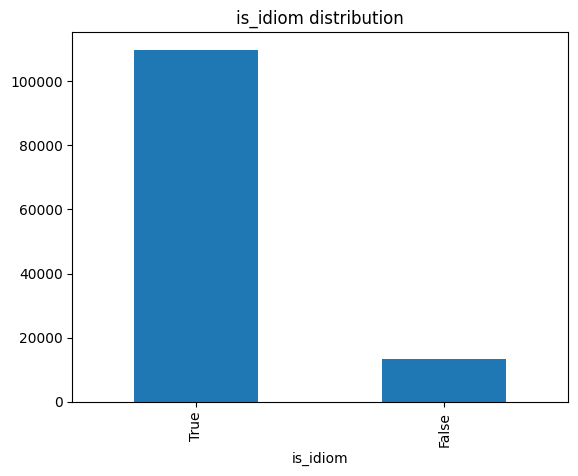

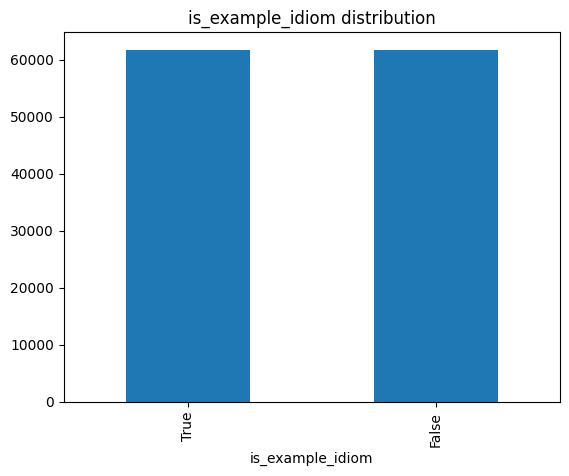

In [19]:
# 6. Class imbalance visualization
# =========================================

import matplotlib.pyplot as plt

# is_idiom
df["is_idiom"].value_counts().plot(kind="bar", title="is_idiom distribution")
plt.show()

# is_example_idiom
df["is_example_idiom"].value_counts().plot(kind="bar", title="is_example_idiom distribution")
plt.show()

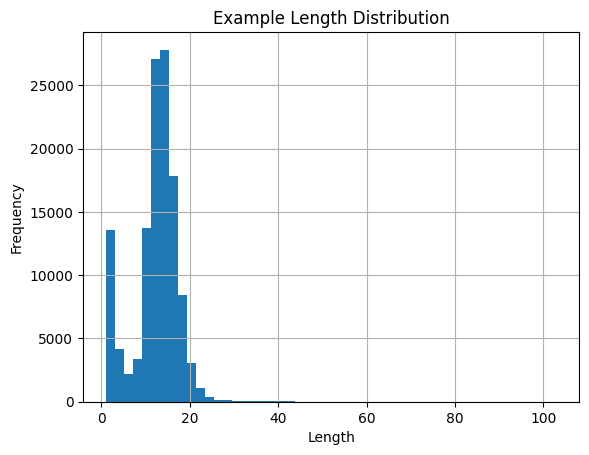

In [20]:
# 6.1. Example length distribution
# =========================================

plt.figure()
df["example_length"].dropna().hist(bins=50)
plt.title("Example Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

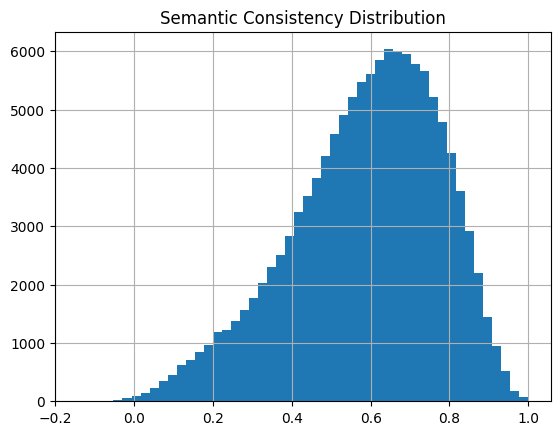

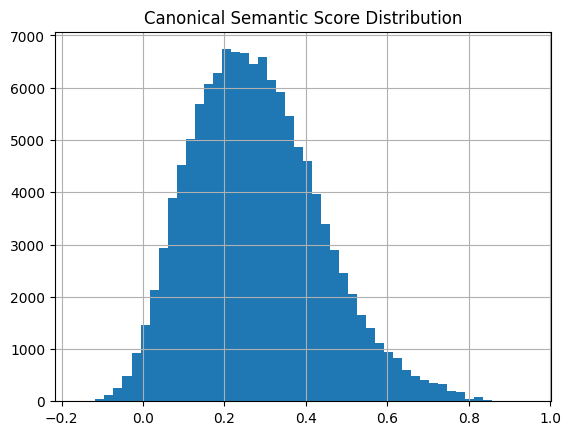

In [21]:
# =========================================
# 6.2. Semantic quality distribution
# =========================================

plt.figure()
df["semantic_consistency"].hist(bins=50)
plt.title("Semantic Consistency Distribution")
plt.show()

plt.figure()
df["canonical_semantic_score"].hist(bins=50)
plt.title("Canonical Semantic Score Distribution")
plt.show()

In [22]:
# 6.3. Check duplicates (important)
# =========================================

duplicate_examples = df.duplicated(subset=["example", "idiom_canonical"]).sum()
duplicate_idioms = df.duplicated(subset=["idiom_canonical"]).sum()

print("Duplicate (example + idiom):", duplicate_examples)
print("Duplicate idiom_canonical :", duplicate_idioms)

Duplicate (example + idiom): 108048
Duplicate idiom_canonical : 108349


In [23]:
# 6.4. Generated vs real quality comparison
# =========================================

df.groupby("is_generated_example")[["semantic_consistency", "canonical_semantic_score"]].mean()

,semantic_consistency,canonical_semantic_score
is_generated_example,,
1,0.587078,0.278083


In [24]:
# 6.5. Binary signals
# =========================================

binary_cols = [
    "is_generated_example",
    "idiom_present",
    "contains_profanity"
]

for col in binary_cols:
    print(f"\n{col} distribution:")
    display(df[col].value_counts(normalize=True) * 100)


is_generated_example distribution:


is_generated_example
1    100.0
Name: proportion, dtype: float64


idiom_present distribution:


idiom_present
True     88.639165
False    11.360835
Name: proportion, dtype: float64


contains_profanity distribution:


contains_profanity
False    98.365441
True      1.634559
Name: proportion, dtype: float64

In [25]:
# 6.6. Categorical linguistic features
# =========================================

cat_cols = [
    "ambiguity_flag",
    "idiom_compositionality_level",
    "idiom_register",
    "idiom_domain",
    "learner_difficulty",
    "validation_status"
]

for col in cat_cols:
    print(f"\nTop values for {col}:")
    display(df[col].value_counts().head(10))


Top values for ambiguity_flag:


ambiguity_flag
semi_literal_possible    80904
strongly_idiomatic       30720
ambiguous                11712
Name: count, dtype: int64


Top values for idiom_compositionality_level:


idiom_compositionality_level
semi_opaque    71296
opaque         29472
transparent    22568
Name: count, dtype: int64


Top values for idiom_register:


...

idiom_domain
general      98680
regional      7616
business      5264
politics      2680
sports        2144
legal         2088
military      1680
internet      1352
biblical       992
religious      840
Name: count, dtype: int64


Top values for learner_difficulty:


learner_difficulty
medium    89528
easy      17552
hard      16256
Name: count, dtype: int64


Top values for validation_status:


validation_status
valid        121079
verified       1531
corrected       726
Name: count, dtype: int64

In [26]:
# 6.7. Example length deeper analysis
# =========================================

print("Example length stats:")
display(df["example_length"].describe())

Example length stats:


count    123334.000000
mean         12.529286
std           5.107134
min           1.000000
25%          11.000000
50%          13.000000
75%          16.000000
max         103.000000
Name: example_length, dtype: float64

In [27]:
# 6.8. Quality vs label (important insight)
# =========================================

df.groupby("is_example_idiom")[[
    "semantic_consistency",
    "canonical_semantic_score"
]].mean()

,semantic_consistency,canonical_semantic_score
is_example_idiom,,
False,0.627423,0.240203
True,0.546801,0.315898


In [28]:
# 6.9. Difficulty vs semantic quality
# =========================================

df.groupby("learner_difficulty")[[
    "semantic_consistency",
    "canonical_semantic_score"
]].mean().sort_values("semantic_consistency", ascending=False)

,semantic_consistency,canonical_semantic_score
learner_difficulty,,
medium,0.601836,0.265886
hard,0.563340,0.253602
easy,0.533785,0.362970


In [36]:
# 6.10 idiom detection model - Label balance
# =========================================
df["example_usage_label"].value_counts()

example_usage_label
idiomatic    61695
literal      61641
Name: count, dtype: int64

## Dataset Overview

The IdiomX dataset consists of **123,336 records** of English idioms enriched with contextual, semantic, and linguistic annotations.

### Key Characteristics

- **Large-scale dataset** with high-quality enrichment, covering idioms, meanings, and contextual usage.
- **Example coverage** reaches approximately **63%**, providing substantial context-based learning signals.
- All examples are **LLM-generated**, ensuring consistency in structure and annotation.

### Linguistic Properties

- Idioms are categorized by:
  - **Compositionality**: primarily *semi-opaque* and *opaque*
  - **Ambiguity**: dominated by *semi-literal possible* and *strongly idiomatic*
  - **Register**: mostly *neutral*, with informal and formal variations
  - **Domain**: largely *general-purpose*, with smaller domain-specific subsets (e.g., business, politics, sports)

- **Learner difficulty** is mainly *medium*, indicating balanced complexity for modeling.

### Semantic Quality

- `semantic_consistency` is centered around **0.6**, indicating good alignment between idioms and their contextual usage.
- `canonical_semantic_score` is lower (~0.25–0.35), reflecting the inherent difficulty of aligning canonical meanings with context.

### Data Distribution

- `is_idiom` is **imbalanced** (~89% True), reflecting the idiom-focused nature of the dataset.
- `is_example_idiom` is **balanced (~50/50)**, making it suitable for context-based classification tasks.
- `idiom_present` aligns closely with idiomatic labeling (~88% True).

### Example Characteristics

- Average example length ≈ **12.5 tokens**, with most examples between 10–16 tokens.
- This range is well-suited for transformer-based models without heavy truncation.

### Data Quality and Safety

- **Very low profanity presence** (~1.6%), ensuring safe usage.
- **Validation status** is overwhelmingly *valid*, with minor verified and corrected subsets.
- Core fields (idiom, meanings, canonical forms) are nearly complete (>99%).

### Additional Observations

- The dataset contains **repeated idioms and examples**, reflecting multiple contextual variations per idiom.
- This structure is beneficial for learning but requires **careful split strategies (by idiom)** to avoid data leakage.

### Conclusion

IdiomX provides a **rich, high-quality, and semantically annotated resource** for idiom understanding tasks, particularly for contextual modeling, multilingual applications, and idiomatic expression learning.

## Semantic Consistency Scoring using Sentence Embeddings

In [53]:
import sys
!{sys.executable} -m pip install -q sentence-transformers

In [54]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

In [ ]:
examples = df["idiom_in_example"].fillna("").tolist()
meanings = df["idiom_in_example_meaning_en"].fillna("").tolist()

emb_examples = model.encode(examples, show_progress_bar=True)
emb_meanings = model.encode(meanings, show_progress_bar=True)

similarities = [
    cosine_similarity([e], [m])[0][0]
    for e, m in zip(emb_examples, emb_meanings)
]

df["semantic_consistency"] = similarities

In [ ]:
df["semantic_consistency"].describe()

In [55]:
# detect suspicious examples
suspicious = df[df["semantic_consistency"] < 0.35]

suspicious[[
    "idiom_canonical",
    "idiom_in_example",
    "idiom_in_example_meaning_en",
    "semantic_consistency"
]].head(5)

,idiom_canonical,idiom_in_example,idiom_in_example_meaning_en,semantic_consistency
10,et ux.,& ux.,"In the document, the parties Smith & ux. are listed as tenants.",0.281240
11,et ux.,& ux.,The law journal referenced the couple as Jones & ux. in the divorce proceedings.,0.229599
13,et ux.,The invoice was addressed to Smith & ux.,Literal usage referring to a husband and his wife named in paperwork.,0.303458
17,'ark at ee,"‘Well, ’ark at ee! Who would have thought you could do that?’",Highlighting surprise about what someone has said or done.,0.257730
18,'ark at ee,‘’Ark at ’ee! You speak as if you’re an expert!’,Pointing out that someone's statement is exaggerated or self-important.,0.221512


In [56]:
(df["semantic_consistency"] < 0.35).mean()

0.12173250308101446

The semantic consistency between generated example sentences and idiom meanings was evaluated using sentence embeddings (all-mpnet-base-v2).
The dataset achieved a mean cosine similarity of 0.61, indicating strong semantic alignment between examples and definitions.

Example vs canonical meaning

    idiom_in_example
    vs
    idiom_canonical_meaning

In [57]:
examples = df["idiom_in_example"].fillna("").tolist()
canonical_meanings = df["idiom_canonical_meaning"].fillna("").tolist()

emb_examples = model.encode(examples, show_progress_bar=True)
emb_meanings = model.encode(canonical_meanings, show_progress_bar=True)

df["canonical_semantic_score"] = [
    cosine_similarity([e], [m])[0][0]
    for e, m in zip(emb_examples, emb_meanings)
]

Batches:   0%|          | 0/3855 [00:00<?, ?it/s]

Batches:   0%|          | 0/3855 [00:00<?, ?it/s]

In [58]:
df[df["semantic_consistency"] < 0.2][["idiom","meaning_en","idiom_in_example","idiom_canonical_meaning"]]

,idiom,meaning_en,idiom_in_example,idiom_canonical_meaning
24,'fraid so,I am afraid so,'fraid so,I am afraid that is the case
25,'fraid so,I am afraid so,'fraid so,I am afraid that is the case
26,'fraid so,I am afraid so,'fraid so,I am afraid that is the case
27,'fraid so,I am afraid so,'fraid so,I am afraid that is the case
168,American cheese,"Used other than figuratively or idiomatically: see American, cheese: any cheese made in America.",American cheese,Refers literally to cheese produced in America; does not have a recognized idiomatic or figurative meaning.
...,...,...,...,...
123114,your man,"Used other than figuratively or idiomatically: see your, man.","Don’t worry, your man is handling the negotiations very well.","A phrase used to refer to a male person associated with or representing someone, often meaning 'your boyfriend', 'yo..."
123209,yours trulies,"we, us, or ourselves",Yours truly will be attending the conference next week.,oneself; me; the speaker referring to themselves
123266,zig when one should zag,To misstep or err.,zig when you should zag,To make a mistake or take an incorrect action at a crucial moment.
123267,zig when one should zag,To misstep or err.,zig instead of zag,To make a mistake or take an incorrect action at a crucial moment.


## 7. Advanced Insights

,semantic_consistency,canonical_semantic_score,example_length
semantic_consistency,1.000000,0.013241,0.284438
canonical_semantic_score,0.013241,1.000000,-0.057675
example_length,0.284438,-0.057675,1.000000


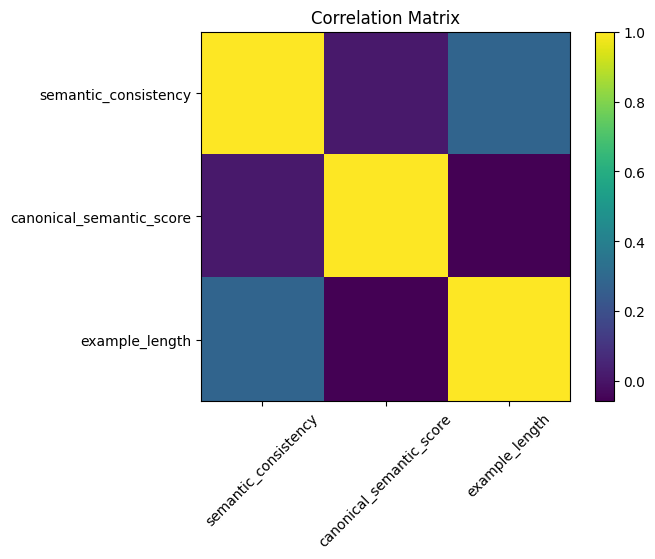

In [29]:
# 7.1 — Correlation matrix (numeric)
# =========================================

num_cols = [
    "semantic_consistency",
    "canonical_semantic_score",
    "example_length"
]

corr = df[num_cols].corr()

display(corr)

import matplotlib.pyplot as plt

plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Matrix")
plt.show()

In [30]:
# 7.2. Compositionality vs quality
# =========================================

df.groupby("idiom_compositionality_level")[[
    "semantic_consistency",
    "canonical_semantic_score"
]].mean().sort_values("semantic_consistency", ascending=False)

,semantic_consistency,canonical_semantic_score
idiom_compositionality_level,,
semi_opaque,0.601653,0.267860
opaque,0.587334,0.235573
transparent,0.540699,0.365892


In [31]:
# 7.3. Ambiguity vs learner difficulty
# =========================================

pd.crosstab(df["ambiguity_flag"], df["learner_difficulty"], normalize="index") * 100

learner_difficulty,easy,hard,medium
ambiguity_flag,,,
ambiguous,6.352459,15.505464,78.142077
semi_literal_possible,20.261050,6.476812,73.262138
strongly_idiomatic,1.354167,29.947917,68.697917


In [32]:

# 7.4. Domain vs quality
# =========================================

df.groupby("idiom_domain")[[
    "semantic_consistency",
    "canonical_semantic_score"
]].mean().sort_values("semantic_consistency", ascending=False).head(10)

,semantic_consistency,canonical_semantic_score
idiom_domain,,
legal,0.603113,0.336479
sports,0.603096,0.292303
business,0.598655,0.304726
politics,0.590808,0.312213
general,0.589723,0.273234
biblical,0.587896,0.305084
military,0.565113,0.304889
regional,0.551781,0.266548
religious,0.548089,0.368403


In [33]:
# 7.5. Register vs usage label
# =========================================

pd.crosstab(df["idiom_register"], df["example_usage_label"], normalize="index") * 100

example_usage_label,idiomatic,literal
idiom_register,,
archaic,50.103673,49.896327
formal,49.871643,50.128357
informal,50.163421,49.836579
neutral,49.969830,50.030170
slang,50.167504,49.832496


In [34]:
# 7.6. Idiom presence vs quality
# =========================================

df.groupby("idiom_present")[[
    "semantic_consistency",
    "canonical_semantic_score"
]].mean()

,semantic_consistency,canonical_semantic_score
idiom_present,,
False,0.642015,0.241416
True,0.580037,0.282782
